# 0.7 pytorch 실험 추적 (Experitent Tracking)

- 목적 : 다양한 모델 만들기 & 여러 데이터, 모델 구조, 학습 방식의 조합 결과를 기록
- 실험 개수 증가시 실험들을 체계적으로 기록하고 관리할 방법이 반드시 필요함

# 주제 및 내용
- FoodVision Mini 성능을 개선하기 위해, 데이터 양, 모델 크기, 학습 시간 등을 다양하게 바꿔가며 여러 모델링 실험을 진행할 예정

0. 환경 설정 - 이전 섹션에서 작성한 유용한 코드들을 다운로드하고 다시 사용할 수 있도록 준비
1. 데이터 가져오기 - FoodVision Mini 성능 향상을 위해 사용해온 피자, 스테이크, 스시 이미지 데이터셋을 가져옴
2. Dataset과 DataLoader 생성 - 05장(PyTorch Going Modular)에서 만든 data_setup.py 스크립트를 사용해 DataLoader를 설정
3. 사전 학습 모델 가져오기 및 커스터마이징 - 이전 섹션(06. Transfer Learning)처럼 torchvision.models에서 사전 학습 모델을 가져와 우리의 문제에 맞게 수정
4. 모델 학습 및 결과 추적 - TensorBoard를 사용해 하나의 모델을 학습시키고 그 결과를 추적
5. TensorBoard에서 결과 확인 - 이전에는 loss 곡선을 함수로 시각화했지만, 이제 TensorBoard에서 어떻게 보이는지 확인
6. 실험 추적용 helper 함수 만들기 -	여러 실험 결과를 저장하기 위한 함수(자동화 도구)를 만듬
7. 여러 실험 설정하기 - 하나씩 실험하는 대신, 서로 다른 모델, 데이터 양, 학습 시간으로 여러 실험을 동시에 실행하는 코드를 작성
8. TensorBoard에서 실험 비교 - 여러 실험 결과를 TensorBoard에서 비교하고 분석
9. 최적 모델 불러오기 및 예측 - 가장 성능이 좋은 모델을 불러와 예측을 수행하고 결과를 시각화


# 0. 환경 설정

In [1]:
try:
    import torch
    import torchvision
    assert int(torch.__version__.split(".")[1]) >= 12, "torch version should be 1.12+"
    assert int(torchvision.__version__.split(".")[1]) >= 13, "torchvision version should be 0.13+"
    print(f"torch version: {torch.__version__}")
    print(f"torchvision version: {torchvision.__version__}")
except:
    print(f"[INFO] torch/torchvision versions not as required, installing nightly versions.")
    import torch
    import torchvision
    print(f"torch version: {torch.__version__}")
    print(f"torchvision version: {torchvision.__version__}")

[INFO] torch/torchvision versions not as required, installing nightly versions.
torch version: 2.5.1+cu121
torchvision version: 0.20.1+cu121


In [2]:
pip uninstall torch torchvision torchaudio -y


Found existing installation: torch 2.5.1+cu121
Uninstalling torch-2.5.1+cu121:
  Successfully uninstalled torch-2.5.1+cu121
Found existing installation: torchvision 0.20.1+cu121
Uninstalling torchvision-0.20.1+cu121:
  Successfully uninstalled torchvision-0.20.1+cu121
Found existing installation: torchaudio 2.5.1+cu121
Uninstalling torchaudio-2.5.1+cu121:
  Successfully uninstalled torchaudio-2.5.1+cu121
Note: you may need to restart the kernel to use updated packages.


You can safely remove it manually.
You can safely remove it manually.


In [3]:
pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

Looking in indexes: https://download.pytorch.org/whl/cu121
  Using cached https://download.pytorch.org/whl/cu121/torch-2.5.1%2Bcu121-cp310-cp310-win_amd64.whl (2449.4 MB)
  Using cached https://download-r2.pytorch.org/whl/cu121/torchvision-0.20.1%2Bcu121-cp310-cp310-win_amd64.whl (6.1 MB)
  Using cached https://download-r2.pytorch.org/whl/cu121/torchaudio-2.5.1%2Bcu121-cp310-cp310-win_amd64.whl (4.1 MB)

   ---------------------------------------- 0/3 [torch]
   ---------------------------------------- 0/3 [torch]
   ---------------------------------------- 0/3 [torch]
   ---------------------------------------- 0/3 [torch]
   ---------------------------------------- 0/3 [torch]
   ---------------------------------------- 0/3 [torch]
   ---------------------------------------- 0/3 [torch]
   ---------------------------------------- 0/3 [torch]
   ---------------------------------------- 0/3 [torch]
   ---------------------------------------- 0/3 [torch]
   -----------------------------

In [4]:
import matplotlib.pyplot as plt
import torch
import torchvision

from torch import nn
from torchvision import transforms

# Try to get torchinfo, install it if it doesn't work
try:
    from torchinfo import summary       # torchinfo.summary: 모델 구조를 요약해서 보여주는 도구
except:
    print("[INFO] Couldn't find torchinfo... installing it.")
    !pip install -q torchinfo
    from torchinfo import summary

# Try to import the going_modular directory, download it from GitHub if it doesn't work
try:
    from going_modular import data_setup, engine
except:
    # Get the going_modular scripts
    print("[INFO] Couldn't find going_modular scripts... downloading them from GitHub.")
    !git clone https://github.com/mrdbourke/pytorch-deep-learning
    !mv pytorch-deep-learning/going_modular .
    !rm -rf pytorch-deep-learning
    from going_modular import data_setup, engine

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [6]:
# 랜덤시드 고정 함수 만들기

def set_seeds(seed: int=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)

# 1. 데이터 가져오기
- 우리는 계속해서 FoodVision Mini의 성능을 개선해보려고 함

- 이전에 사용했던 피자, 스테이크, 스시 이미지 데이터들을 다운하는 과정을 함수로 만들기

In [7]:
import os
import zipfile

from pathlib import Path

import requests

def download_data(source: str, 
                  destination: str,
                  remove_source: bool = True) -> Path:
    # Setup path to data folder
    data_path = Path("data/")
    image_path = data_path / destination

    # If the image folder doesn't exist, download it and prepare it... 
    if image_path.is_dir():
        print(f"[INFO] {image_path} directory exists, skipping download.")
    else:
        print(f"[INFO] Did not find {image_path} directory, creating one...")
        image_path.mkdir(parents=True, exist_ok=True)
        
        # 데이터 다운로드
        target_file = Path(source).name
        with open(data_path / target_file, "wb") as f:
            request = requests.get(source)
            print(f"[INFO] Downloading {target_file} from {source}...")
            f.write(request.content)

        # 압축 해제
        with zipfile.ZipFile(data_path / target_file, "r") as zip_ref:
            print(f"[INFO] Unzipping {target_file} data...") 
            zip_ref.extractall(image_path)

        # Remove .zip file
        if remove_source:
            os.remove(data_path / target_file)
    
    return image_path

image_path = download_data(source="https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip",
                           destination="pizza_steak_sushi")
image_path


[INFO] data\pizza_steak_sushi directory exists, skipping download.


WindowsPath('data/pizza_steak_sushi')

# 2. Dataset과 DataLoader 생성


- 준비한 데이터를 pytorch dataloader로 변환- create_dataloaders()
- 전이 학습(transfer learning)을 사용할 것이고, <br>
특히 torchvision.models의 사전 학습 모델을 사용할 예정임<br>
-> 전처리 만들어야 함

-  이미지 -> 텐서로 변환하는 법
1. 직접 transform 만들기
2. 사전 학습 모델에 맞는 transforms 자동 사용

*직접 transform 만들 때 중요한 것 <br>
이미지를 ImageNet 기준으로 정규화해야 한다는 것 -> torchvision의 사전 학습 모델들은 모두 ImageNet 데이터로 학습되기 때문

# 2.1 직접 만든 transforms 이용해 dataloaders 만들기

In [8]:
# Setup directories
train_dir = image_path / "train"
test_dir = image_path / "test"

# Setup ImageNet normalization levels (turns all images into similar distribution as ImageNet)
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])

# Create transform pipeline manually
manual_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    normalize
])           
print(f"Manually created transforms: {manual_transforms}")

# Create data loaders
train_dataloader, test_dataloader, class_names = data_setup.create_dataloaders(
    train_dir=train_dir,
    test_dir=test_dir,
    transform=manual_transforms, # use manually created transforms
    batch_size=32
)

train_dataloader, test_dataloader, class_names

Manually created transforms: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


(<torch.utils.data.dataloader.DataLoader at 0x22c04095ed0>,
 ['pizza', 'steak', 'sushi'])

# 2.2 자동으로 생성된 transforms를 사용해 DataLoader 만들기

- 이제 동일한 변환(transform) 과정을 자동 transforms를 사용해서 어떻게 구현하는지 살펴보기<br>
- 이를 위해 먼저 사용할 사전 학습 가중치 생성하기<br>
ex) weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT <br>
이 다음 이 가중치에 포함된 transforms() 메서드를 호출하면 해당 모델에 맞는 최적의 전처리 파이프라인을 자동으로 얻을 수 있음

In [10]:
# Setup dirs
train_dir = image_path / "train"
test_dir = image_path / "test"

# Setup pretrained weights (plenty of these available in torchvision.models)
weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT

# Get transforms from weights (these are the transforms that were used to obtain the weights)
automatic_transforms = weights.transforms() 
print(f"Automatically created transforms: {automatic_transforms}")

# Create data loaders
train_dataloader, test_dataloader, class_names = data_setup.create_dataloaders(
    train_dir=train_dir,
    test_dir=test_dir,
    transform=automatic_transforms, # use automatic created transforms
    batch_size=32
)

train_dataloader, test_dataloader, class_names

Automatically created transforms: ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BICUBIC
)


(<torch.utils.data.dataloader.DataLoader at 0x22c04d47ca0>,
 ['pizza', 'steak', 'sushi'])

# 3. 사전 학습 모델 가져오기, 기본 레이어 고정, 분류기 변경

- 여러 모델링 실험을 실행하고 추적하기 전에,
먼저 하나의 실험을 실행하고 추적하는 과정을 살펴보기

- torchvision.models.efficientnet_b0() 모델의
사전 학습 가중치(pretrained weights)를 다운로드하고,
이를 우리 데이터에 맞게 사용할 수 있도록 준비

In [12]:
# Download the pretrained weights for EfficientNet_B0
weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT # NEW in torchvision 0.13, "DEFAULT" means "best weights available"

# Setup the model with the pretrained weights and send it to the target device
model = torchvision.models.efficientnet_b0(weights=weights).to(device)

- 사전 학습된 모델을 가져왔으니, 이를 feature extractor 모델로 바꾸기

- 핵심 개념

1. 모델의 기본 레이어(base layers)는 고정(freeze) <br>
이 부분은 입력 이미지로부터 특징(feature)을 추출하는 데 사용됨
2. 대신 분류기(classifier head, 출력층)는 우리가 다루는 클래스 수에 맞게 변경<br>
현재 클래스는 3개

In [13]:
# Freeze all base layers by setting requires_grad attribute to False
for param in model.features.parameters():
    param.requires_grad = False
    
# Since we're creating a new layer with random weights (torch.nn.Linear), 
# let's set the seeds
set_seeds() 

# Update the classifier head to suit our problem
model.classifier = torch.nn.Sequential(
    nn.Dropout(p=0.2, inplace=True),    # 과적합 방지용 20%뉴런 제거
    nn.Linear(in_features=1280, 
              out_features=len(class_names),
              bias=True).to(device))

In [15]:
from torchinfo import summary

summary(model, 
         input_size=(32, 3, 224, 224), # make sure this is "input_size", not "input_shape" (batch_size, color_channels, height, width)
         verbose=0,
         col_names=["input_size", "output_size", "num_params", "trainable"],
         col_width=20,
         row_settings=["var_names"]
 )

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                                      [32, 3, 224, 224]    [32, 1280, 7, 7]     --                   False
│    └─Conv2dNormActivation (0)                              [32, 3, 224, 224]    [32, 32, 112, 112]   --                   False
│    │    └─Conv2d (0)                                       [32, 3, 224, 224]    [32, 32, 112, 112]   (864)                False
│    │    └─BatchNorm2d (1)                                  [32, 32, 112, 112]   [32, 32, 112, 112]   (64)                 False
│    │    └─SiLU (2)                                         [32, 32, 112, 112]   [32, 32, 112, 112]   --                   --
│    └─Sequential (1)                                        [32, 32, 112, 112]   [32, 

# 4. 모델 학습 & 결과 추적

In [16]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

- torch.utils.tensorboard.SummaryWriter() 클래스 <br>
: 모델 학습 과정에서 발생하는 다양한 정보를 파일로 저장해줌

- SummaryWriter() <br>
: log_dir 파라미터로 지정된 위치에 학습 정보를 저장
-log_dir를 직접 지정하면 원하는 위치, 원하는 이름으로 실험 기록 가능
-SummaryWriter가 저장하는 파일은 TensorBoard 형식

*TensorBoard <br>
딥러닝 모델의 학습 과정을 시각화(그래프, 곡선 등)

In [17]:
try:
    from torch.utils.tensorboard import SummaryWriter
except:
    print("[INFO] Couldn't find tensorboard... installing it.")
    !pip install -q tensorboard
    from torch.utils.tensorboard import SummaryWriter


# Create a writer with all default settings
writer = SummaryWriter()

[INFO] Couldn't find tensorboard... installing it.


- writer 사용하기
- engine.py에 있는 train() 함수를 가져와서  writer를 사용하도록 수정할 예정
-모델의 학습(train)과 테스트(test) 과정에서의 loss와 accuracy 값을 기록(log)할 수 있도록 기능을 추가
- 기록 방식 - writer.add_scalars(main_tag, tag_scalar_dict)
1. main_tag (문자열): 추적할 값의 이름 (예: "Accuracy")
2. tag_scalar_dict (딕셔너리): 기록할 값들
(예: {"train_loss": 0.3454})


In [19]:
from typing import Dict, List
from tqdm.auto import tqdm

from going_modular.engine import train_step, test_step

# Import train() function from: 
# https://github.com/mrdbourke/pytorch-deep-learning/blob/main/going_modular/going_modular/engine.py
def train(model: torch.nn.Module, 
          train_dataloader: torch.utils.data.DataLoader, 
          test_dataloader: torch.utils.data.DataLoader, 
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module,
          epochs: int,
          device: torch.device) -> Dict[str, List]:
    """PyTorch 모델을 학습하고 테스트합니다.

주어진 PyTorch 모델을 train_step()과 test_step() 함수에 전달하여
여러 epoch 동안 학습과 테스트를 같은 루프에서 수행합니다.

학습 과정 동안 평가 지표를 계산하고, 출력하고, 저장합니다.

Args:
  model: 학습 및 테스트할 PyTorch 모델
  train_dataloader: 학습용 DataLoader
  test_dataloader: 테스트용 DataLoader
  optimizer: 손실 함수를 최소화하기 위한 PyTorch 옵티마이저
  loss_fn: 학습/테스트 데이터에 대한 손실을 계산하는 손실 함수
  epochs: 학습 epoch 수 (정수)
  device: 연산을 수행할 장치 (예: "cuda" 또는 "cpu")

Returns:
  학습 및 테스트 손실과 정확도를 담은 딕셔너리 반환.
  각 값은 epoch마다의 결과가 리스트로 저장됨.

  형태:
  {
    train_loss: [...],
    train_acc: [...],
    test_loss: [...],
    test_acc: [...]
  }

  예시 (epochs=2일 때):
  {
    train_loss: [2.0616, 1.0537],
    train_acc: [0.3945, 0.3945],
    test_loss: [1.2641, 1.5706],
    test_acc: [0.3400, 0.2973]
  }
"""
   
    # Create empty results dictionary
    results = {"train_loss": [],
               "train_acc": [],
               "test_loss": [],
               "test_acc": []
    }

    # Loop through training and testing steps for a number of epochs
    for epoch in tqdm(range(epochs)):
        train_loss, train_acc = train_step(model=model,
                                           dataloader=train_dataloader,
                                           loss_fn=loss_fn,
                                           optimizer=optimizer,
                                           device=device)
        test_loss, test_acc = test_step(model=model,
                                        dataloader=test_dataloader,
                                        loss_fn=loss_fn,
                                        device=device)

        # Print out what's happening
        print(
          f"Epoch: {epoch+1} | "
          f"train_loss: {train_loss:.4f} | "
          f"train_acc: {train_acc:.4f} | "
          f"test_loss: {test_loss:.4f} | "
          f"test_acc: {test_acc:.4f}"
        )

        # Update results dictionary
        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["test_loss"].append(test_loss)
        results["test_acc"].append(test_acc)

        ### New: Experiment tracking ###
        # Add loss results to SummaryWriter
        writer.add_scalars(main_tag="Loss", 
                           tag_scalar_dict={"train_loss": train_loss,
                                            "test_loss": test_loss},
                           global_step=epoch)

        # Add accuracy results to SummaryWriter
        writer.add_scalars(main_tag="Accuracy", 
                           tag_scalar_dict={"train_acc": train_acc,
                                            "test_acc": test_acc}, 
                           global_step=epoch)
        
        # Track the PyTorch model architecture
        writer.add_graph(model=model, 
                         # Pass in an example input
                         input_to_model=torch.randn(32, 3, 224, 224).to(device))
    
    # Close the writer
    writer.close()
    
    ### End new ###

    # Return the filled results at the end of the epochs
    return results

In [20]:
set_seeds()
results = train(model=model,
                train_dataloader=train_dataloader,
                test_dataloader=test_dataloader,
                optimizer=optimizer,
                loss_fn=loss_fn,
                epochs=5,
                device=device)

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.0924 | train_acc: 0.3984 | test_loss: 0.9131 | test_acc: 0.5398
Epoch: 2 | train_loss: 0.8975 | train_acc: 0.6562 | test_loss: 0.7837 | test_acc: 0.8561
Epoch: 3 | train_loss: 0.8038 | train_acc: 0.7461 | test_loss: 0.6722 | test_acc: 0.8864
Epoch: 4 | train_loss: 0.6770 | train_acc: 0.8516 | test_loss: 0.6698 | test_acc: 0.8049
Epoch: 5 | train_loss: 0.7065 | train_acc: 0.7188 | test_loss: 0.6745 | test_acc: 0.7737


-> 06. PyTorch Transfer Learning 섹션 4(모델 학습)에서 얻었던 것과 비슷한 출력이 나오지만, <br>
차이점은 보이지 않는 내부에서 writer가 runs/ 디렉토리를 생성해 모델 결과를 저장한다는 것 <br>
기본 형식 - runs/현재날짜_컴퓨터이름

# 5. TensorBoard에서 모델 결과 확인하기

- SummaryWriter() 클래스는 기본적으로 -> 모델 결과를 TensorBoard 형식으로 runs/ 디렉토리에 저장
- TensorBoard 
: TensorFlow 팀에서 만든 시각화 도구 

# 6. SummaryWriter() 생성을 위한 helper 함수 만들기

- SummaryWriter() 클래스 : log_dir 파라미터로 지정된 디렉토리에 다양한 정보를 기록 <br>
- 각 실험마다 별도의 디렉토리를 자동으로 생성하는 함수를 만들기<br>

- 목표 : 각 실험마다 고유한 로그 폴더 생성 <br>
-다음과 같은 정보 포함 가능 

실험 날짜/시간: 언제 실행됐는지 <br>
실험 이름: 실험을 구분하기 위한 이름 <br>
모델 이름: 어떤 모델을 사용했는지 <br>
추가 정보(extra): 기타 필요한 정보 <br>


- 만들 함수 : create_writer()라는 helper 함수 <br>
커스텀 log_dir를 가지는 SummaryWriter 객체를 생성하는 함수 
- 원하는 log_dir 구조 <br>
runs/YYYY-MM-DD/experiment_name/model_name/extra


*로그 : 모델 학습 과정에서 나오는 값들을 저장해둔 것

In [21]:
def create_writer(experiment_name: str, 
                  model_name: str, 
                  extra: str=None) -> torch.utils.tensorboard.writer.SummaryWriter():
    """특정 log_dir에 저장하는 torch.utils.tensorboard.writer.SummaryWriter() 인스턴스를 생성합니다.

log_dir은 runs/타임스탬프/실험이름/모델이름/추가정보 형태로 구성됩니다.

   여기서 타임스탬프는 YYYY-MM-DD 형식의 현재 날짜입니다.

Args:
    experiment_name (str): 실험 이름
    model_name (str): 모델 이름
    extra (str, optional): 디렉토리에 추가할 정보 (기본값: None)

Returns:
    torch.utils.tensorboard.writer.SummaryWriter:
    지정된 log_dir에 저장하는 writer 인스턴스

Example usage:
    # "runs/2022-06-04/data_10_percent/effnetb2/5_epochs/" 경로에 저장하는 writer 생성
    writer = create_writer(experiment_name="data_10_percent",
                           model_name="effnetb2",
                           extra="5_epochs")

    # 위 코드는 아래와 동일:
    writer = SummaryWriter(
        log_dir="runs/2022-06-04/data_10_percent/effnetb2/5_epochs/"
    )
    """
    from datetime import datetime
    import os

    # Get timestamp of current date (all experiments on certain day live in same folder)
    timestamp = datetime.now().strftime("%Y-%m-%d") # returns current date in YYYY-MM-DD format

    if extra:   
        # Create log directory path
        log_dir = os.path.join("runs", timestamp, experiment_name, model_name, extra)
    else:
        log_dir = os.path.join("runs", timestamp, experiment_name, model_name)
        
    print(f"[INFO] Created SummaryWriter, saving to: {log_dir}...")
    return SummaryWriter(log_dir=log_dir)

In [22]:
example_writer = create_writer(experiment_name="data_10_percent",
                               model_name="effnetb0",
                               extra="5_epochs")

[INFO] Created SummaryWriter, saving to: runs\2026-03-30\data_10_percent\effnetb0\5_epochs...


# 6.1 ) train() 함수에 writer 파라미터 추가
train 함수에 writer를 연결해서 실험마다 독립적으로 로그를 기록할 수 있게 만드는 단계

- train() 함수 writer 파라미터를 받을 수 있도록 만들기 <BR>
-> 이렇게 하면 train()를 호출할 때마다 사용 중인 SummaryWriter 인스턴스를 직접 업데이트할 수 있음

- 필요한 이유 - 여러 모델로 여러 실험을 반복 실행할 때 train() 함수를 여러 번 호출하게되는데 <BR>
이때 각 실험마다 다들 writer을 사용하는 것이 좋음

- 핵심 개념 <br>
실험 하나당 writer 하나 = 실험 하나당 logs 디렉토리 하나

In [23]:
from typing import Dict, List
from tqdm.auto import tqdm

# 학습하면서 loss/accuracy를 TensorBoard에 자동 기록하는 train 함수
def train(model: torch.nn.Module, 
          train_dataloader: torch.utils.data.DataLoader, 
          test_dataloader: torch.utils.data.DataLoader, 
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module,
          epochs: int,
          device: torch.device, 
          writer: torch.utils.tensorboard.writer.SummaryWriter # new parameter to take in a writer
          ) -> Dict[str, List]:
    """PyTorch 모델을 학습하고 테스트합니다.

주어진 PyTorch 모델을 train_step()과 test_step() 함수에 전달하여
여러 epoch 동안 학습과 테스트를 같은 루프에서 수행합니다.

학습 과정 동안 평가 지표를 계산하고, 출력하고, 저장합니다.

writer가 주어지면 지정된 log_dir에 메트릭을 기록합니다.

Args:
  model: 학습 및 테스트할 PyTorch 모델
  train_dataloader: 학습용 DataLoader
  test_dataloader: 테스트용 DataLoader
  optimizer: 손실 함수를 최소화하기 위한 PyTorch 옵티마이저
  loss_fn: 학습/테스트 데이터의 손실을 계산하는 함수
  epochs: 학습 epoch 수 (정수)
  device: 연산을 수행할 장치 (예: "cuda" 또는 "cpu")
  writer: 모델 결과를 기록할 SummaryWriter 인스턴스

Returns:
  학습 및 테스트 손실과 정확도를 담은 딕셔너리 반환.
  각 값은 epoch마다 리스트 형태로 저장됨.

  형태:
  {
    train_loss: [...],
    train_acc: [...],
    test_loss: [...],
    test_acc: [...]
  }

  예시 (epochs=2일 때):
  {
    train_loss: [2.0616, 1.0537],
    train_acc: [0.3945, 0.3945],
    test_loss: [1.2641, 1.5706],
    test_acc: [0.3400, 0.2973]
  }
"""
    # Create empty results dictionary
    results = {"train_loss": [],
               "train_acc": [],
               "test_loss": [],
               "test_acc": []
    }

    # Loop through training and testing steps for a number of epochs  - 진행바
    for epoch in tqdm(range(epochs)):
        train_loss, train_acc = train_step(model=model,
                                          dataloader=train_dataloader,
                                          loss_fn=loss_fn,
                                          optimizer=optimizer,
                                          device=device)
        test_loss, test_acc = test_step(model=model,
          dataloader=test_dataloader,
          loss_fn=loss_fn,
          device=device)

        # Print out what's happening
        print(
          f"Epoch: {epoch+1} | "
          f"train_loss: {train_loss:.4f} | "
          f"train_acc: {train_acc:.4f} | "
          f"test_loss: {test_loss:.4f} | "
          f"test_acc: {test_acc:.4f}"
        )

        # Update results dictionary - 결과 저장
        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["test_loss"].append(test_loss)
        results["test_acc"].append(test_acc)


        ### New: Use the writer parameter to track experiments ###
        # writer 있으면 기록 시작
        if writer:
            # Add results to SummaryWriter
            writer.add_scalars(main_tag="Loss", 
                               tag_scalar_dict={"train_loss": train_loss,
                                                "test_loss": test_loss},
                               global_step=epoch) # x축. 시간/epoch 역할
            writer.add_scalars(main_tag="Accuracy", 
                               tag_scalar_dict={"train_acc": train_acc,
                                                "test_acc": test_acc}, 
                               global_step=epoch)

            # Close the writer
            writer.close()
        else:
            pass
    ### End new ###

    # Return the filled results at the end of the epochs
    return results

# 7. 여러 모델링 실험 설정하기

# 7.1 어떤 실험을 해야할까

- 실험의 기준이 되는 것들 -> 하이퍼파라미터 
epoch 수 변경,
레이어 수 / hidden unit 수 변경,
데이터 양 변경,
learning rate 변경,
데이터 증강 방식 변경,
다른 모델 구조 사용

- 첫 실험들을 몇 초~ 몇 분 안에 빨리 끝내는 것이 좋음 <br>
빨리 돌릴수록 무엇이 안 되는지 빨리 알 수 있고
결국 무엇이 되는지도 빨리 찾을 수 있음

# 7.2 우리가 할 실험

목표 : FoodVision Mini 모델 성능 개선, 너무 무겁지 않게 유지

- 이상적인 모델 : 테스트 정확도 90% 이상. 학습/추론 속도 빠름

- 실험 설정 (간단하게)
1. 데이터 양<br>
10% vs 20%
2. 모델<br>
efficientnet_b0
efficientnet_b2
3. 학습 시간<br>
5 epochs
10 epochs

# 7.3 다양한 데이터셋 다운로드

- 학습 데이터는 두 가지 버전 필요
1. 10% 데이터-Food101 중 pizza, steak, sushi의 10%
(이미 만들었지만, 다시 한 번 생성)
2. 20% 데이터-동일 클래스의 20%

- 테스트 데이터는 모든 실험에서 동일한 테스트셋 사용
-> 10% 데이터에서 만든 테스트셋 사용

In [24]:
#  이제 앞에서 만든 download_data() 함수를 사용해서 필요한 데이터셋들을 다운로드
# Download 10 percent and 20 percent training data (if necessary)
data_10_percent_path = download_data(source="https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip",
                                     destination="pizza_steak_sushi")

data_20_percent_path = download_data(source="https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi_20_percent.zip",
                                     destination="pizza_steak_sushi_20_percent")

[INFO] data\pizza_steak_sushi directory exists, skipping download.
[INFO] Did not find data\pizza_steak_sushi_20_percent directory, creating one...
[INFO] Downloading pizza_steak_sushi_20_percent.zip from https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi_20_percent.zip...
[INFO] Unzipping pizza_steak_sushi_20_percent.zip data...


- 다양한 실험에서 사용할 데이터 경로(filepaths)를 설정 <br>
-각 실험마다 사용할 학습 데이터 디렉토리 경로는 다르게 설정할 것<br>
-테스트 데이터는 모든 실험에서 동일하게 사용할 것이기 때문에, 테스트 디렉토리 경로는 하나만 있으면 됨

In [25]:
# Setup training directory paths
train_dir_10_percent = data_10_percent_path / "train"
train_dir_20_percent = data_20_percent_path / "train"

# Setup testing directory paths (note: use the same test dataset for both to compare the results)
test_dir = data_10_percent_path / "test"

# Check the directories
print(f"Training directory 10%: {train_dir_10_percent}")
print(f"Training directory 20%: {train_dir_20_percent}")
print(f"Testing directory: {test_dir}")

Training directory 10%: data\pizza_steak_sushi\train
Training directory 20%: data\pizza_steak_sushi_20_percent\train
Testing directory: data\pizza_steak_sushi\test


# 7.4 데이터 변환 및 DataLoader 생성
모델에 맞게 이미지를 준비하기 위해 -> 여러 transform(전처리)를 생성

- 직접 transform을 만들고, 모든 데이터셋에 동일한 transform을 적용 --> 일관성 유지 <br>

- 이 transform이 하는 일
1. 이미지 크기 조정<br>
모든 이미지를 (224, 224)로 리사이즈(다른 크기로 변경 가능)
2. 텐서로 변환<br>
이미지를 PyTorch 텐서로 변환<br>
값 범위: 0 ~ 1<br>
3. 정규화 (Normalization)<br>
이미지 값을 ImageNet 기준에 맞게 정규화<br>
(우리가 사용하는 torchvision.models의 사전 학습 모델들이 ImageNet 데이터로 학습되었기 때문)

In [26]:
from torchvision import transforms

# Create a transform to normalize data distribution to be inline with ImageNet
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], # 평균.values per colour channel [red, green, blue]
                                 std=[0.229, 0.224, 0.225]) # 표준편차.values per colour channel [red, green, blue]

# 여러 변환을 순서대로 적용
simple_transform = transforms.Compose([
    transforms.Resize((224, 224)), # 1. Resize the images - 224는 EfficientNet 기본 입력 크기
    transforms.ToTensor(), # 2. Turn the images into tensors with values between 0 & 1
    normalize # 3. Normalize the images so their distributions match the ImageNet dataset 
])

- 이제 전에 만들었던 data_setup.py의 create_dataloaders() 함수를 사용해서 DataLoader를 생성하기 <br>
-batch size = 32로 DataLoader를 생성<br>
-모든 실험에서 같은 test_dataloader를 사용할 것 - 실험 간 비교를 일관되게 유지하기 위해<br>

In [27]:
BATCH_SIZE = 32     # 한 번에 모델에 넣을 이미지 개수 = 32장

# Create 10% training and test DataLoaders
train_dataloader_10_percent, test_dataloader, class_names = data_setup.create_dataloaders(train_dir=train_dir_10_percent,
    test_dir=test_dir, 
    transform=simple_transform,
    batch_size=BATCH_SIZE
)

# Create 20% training and test data DataLoders
train_dataloader_20_percent, test_dataloader, class_names = data_setup.create_dataloaders(train_dir=train_dir_20_percent,
    test_dir=test_dir,
    transform=simple_transform,
    batch_size=BATCH_SIZE
)

# Find the number of samples/batches per dataloader (using the same test_dataloader for both experiments)
print(f"Number of batches of size {BATCH_SIZE} in 10 percent training data: {len(train_dataloader_10_percent)}")        # 총 배치 개수
print(f"Number of batches of size {BATCH_SIZE} in 20 percent training data: {len(train_dataloader_20_percent)}")
print(f"Number of batches of size {BATCH_SIZE} in testing data: {len(test_dataloader)} (all experiments will use the same test set)")
print(f"Number of classes: {len(class_names)}, class names: {class_names}")

Number of batches of size 32 in 10 percent training data: 8
Number of batches of size 32 in 20 percent training data: 15
Number of batches of size 32 in testing data: 3 (all experiments will use the same test set)
Number of classes: 3, class names: ['pizza', 'steak', 'sushi']


# 7.5 Feature Extractor 모델 만들기

- 우리는 두 개의 feature extractor 모델을 만들 것
1. torchvision.models.efficientnet_b0() <br>
→ 사전 학습된 backbone + 커스텀 classifier (EffNetB0)
2. torchvision.models.efficientnet_b2()<br>
→ 사전 학습된 backbone + 커스텀 classifier (EffNetB2)

- base layer(특징 추출 부분)는 freeze -> classifier head(출력층)는 우리 문제에 맞게 수정해 만들기

- effnetb2.classifier : EffNetB2의 classifier 입력 크기 확인


*feature extractor : 입력 데이터(이미지)에서 “특징(feature)”만 뽑아내는 부분

In [29]:
import torchvision
from torchinfo import summary

# 1. Create an instance of EffNetB2 with pretrained weights
effnetb2_weights = torchvision.models.EfficientNet_B2_Weights.DEFAULT # "DEFAULT" means best available weights
effnetb2 = torchvision.models.efficientnet_b2(weights=effnetb2_weights)

# # 2. Get a summary of standard EffNetB2 from torchvision.models (uncomment for full output)
summary(model=effnetb2, 
         input_size=(32, 3, 224, 224), # make sure this is "input_size", not "input_shape". 모델에 들어가는 데이터 예시
         # col_names=["input_size"], # uncomment for smaller output
         col_names=["input_size", "output_size", "num_params", "trainable"],
         col_width=20,
         row_settings=["var_names"]
 ) 

# 3. EffNetB2의 마지막 레이어 입력 크기(in_features=1408)를 알아내서 classifier를 바꾸기 위한 코드
print(f"Number of in_features to final layer of EfficientNetB2: {len(effnetb2.classifier.state_dict()['1.weight'][0])}")

Downloading: "https://download.pytorch.org/models/efficientnet_b2_rwightman-c35c1473.pth" to C:\Users\yoonseo/.cache\torch\hub\checkpoints\efficientnet_b2_rwightman-c35c1473.pth
100%|██████████| 35.2M/35.2M [00:00<00:00, 104MB/s]


Number of in_features to final layer of EfficientNetB2: 1408


- EffNetB0와 EffNetB2 feature extractor 모델을 설정하는 helper 함수 만들기
포함되어야 할 기능들
1. torchvision.models에서 기본 모델 가져오기
2. 모델의 base layer를 freeze하기 <br>
→ requires_grad=False 설정<br>
3. 랜덤 시드 설정
→ 여러 실험에서 동일한 조건을 맞추기 위해 사용<br>
→ 특히 새로운 레이어가 랜덤으로 초기화되기 때문<br>
4. classifier head 수정하기
→ 우리의 문제(3개 클래스)에 맞게 변경<br>
5. 모델 이름 지정하기
→ 예: "effnetb0", "effnetb2"

In [31]:
import torchvision
from torch import nn

# 실험 할 때마다 모델을 쉽게 만들기 위한 함수
# Get num out features (one for each class pizza, steak, sushi)
OUT_FEATURES = len(class_names)

# Create an EffNetB0 feature extractor
def create_effnetb0():
    # 1. Get the base model with pretrained weights and send to target device
    weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT
    model = torchvision.models.efficientnet_b0(weights=weights).to(device)

    # 2. Freeze the base model layers - 특징 추출 부분 학습 안 함
    for param in model.features.parameters():
        param.requires_grad = False     

    # 3. Set the seeds
    set_seeds()

    # 4. Change the classifier head
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.2),
        nn.Linear(in_features=1280, out_features=OUT_FEATURES)
    ).to(device)

    # 5. Give the model a name
    model.name = "effnetb0"     # 실험 구분용
    print(f"[INFO] Created new {model.name} model.")
    return model

# Create an EffNetB2 feature extractor
def create_effnetb2():
    # 1. Get the base model with pretrained weights and send to target device
    weights = torchvision.models.EfficientNet_B2_Weights.DEFAULT
    model = torchvision.models.efficientnet_b2(weights=weights).to(device)

    # 2. Freeze the base model layers
    for param in model.features.parameters():
        param.requires_grad = False

    # 3. Set the seeds
    set_seeds()

    # 4. Change the classifier head
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3),      # feature 크기가 커서 과족합 방지 더 강하게 함
        nn.Linear(in_features=1408, out_features=OUT_FEATURES)
    ).to(device)

    # 5. Give the model a name
    model.name = "effnetb2"
    print(f"[INFO] Created new {model.name} model.")
    return model

In [34]:
effnetb0 = create_effnetb0() 

# Get an output summary of the layers in our EffNetB0 feature extractor model (uncomment to view full output)
summary(model=effnetb0, 
         input_size=(32, 3, 224, 224), # make sure this is "input_size", not "input_shape"
         # col_names=["input_size"], # uncomment for smaller output
         col_names=["input_size", "output_size", "num_params", "trainable"],
         col_width=20,
         row_settings=["var_names"]
 )

[INFO] Created new effnetb0 model.


Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                                      [32, 3, 224, 224]    [32, 1280, 7, 7]     --                   False
│    └─Conv2dNormActivation (0)                              [32, 3, 224, 224]    [32, 32, 112, 112]   --                   False
│    │    └─Conv2d (0)                                       [32, 3, 224, 224]    [32, 32, 112, 112]   (864)                False
│    │    └─BatchNorm2d (1)                                  [32, 32, 112, 112]   [32, 32, 112, 112]   (64)                 False
│    │    └─SiLU (2)                                         [32, 32, 112, 112]   [32, 32, 112, 112]   --                   --
│    └─Sequential (1)                                        [32, 32, 112, 112]   [32, 

In [35]:
effnetb2 = create_effnetb2()

# Get an output summary of the layers in our EffNetB2 feature extractor model (uncomment to view full output)
summary(model=effnetb2, 
         input_size=(32, 3, 224, 224), # make sure this is "input_size", not "input_shape"
         # col_names=["input_size"], # uncomment for smaller output
         col_names=["input_size", "output_size", "num_params", "trainable"],
         col_width=20,
         row_settings=["var_names"]
 )

[INFO] Created new effnetb2 model.


Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                                      [32, 3, 224, 224]    [32, 1408, 7, 7]     --                   False
│    └─Conv2dNormActivation (0)                              [32, 3, 224, 224]    [32, 32, 112, 112]   --                   False
│    │    └─Conv2d (0)                                       [32, 3, 224, 224]    [32, 32, 112, 112]   (864)                False
│    │    └─BatchNorm2d (1)                                  [32, 32, 112, 112]   [32, 32, 112, 112]   (64)                 False
│    │    └─SiLU (2)                                         [32, 32, 112, 112]   [32, 32, 112, 112]   --                   --
│    └─Sequential (1)                                        [32, 32, 112, 112]   [32, 

-> EffNetB2 모델의 요약 :base layer는 freeze되어 학습되지 않으며,<br>
classifier는 pizza, steak, sushi 분류에 맞게 수정된 상태<br>

- EffNetB2의 backbone은 EffNetB0보다 거의 2배에 가까운 파라미터 수를 가지고 있음 <br>
-> 이는 EffNetB2의 backbone이
pizza, steak, sushi 데이터를 더 잘 표현할 수 있는
더 많은 학습 능력(표현력)을 가진다는 의미<br>
-> 하지만 실제로 학습되는 파라미터(= classifier 부분)는 두 모델 간 큰 차이가 없음<br>

- 추가적인 파라미터가 더 좋은 성능으로 이어지는지는 실험해보아야 알 수 있음<br>

# 7.6 실험 생성 및 학습 코드 설정

- 먼저 다음을 정의해야 함
1. epoch 리스트-테스트할 학습 횟수
예: [5, 10]<br>
2. 모델 리스트-사용할 모델 종류
예: ["effnetb0", "effnetb2"]<br>
3. DataLoader 딕셔너리-서로 다른 학습 데이터셋을 관리하기 위한 구조

In [36]:
# 1. Create epochs list
num_epochs = [5, 10]

# 2. Create models list (need to create a new model for each experiment)
models = ["effnetb0", "effnetb2"]

# 3. Create dataloaders dictionary for various dataloaders
train_dataloaders = {"data_10_percent": train_dataloader_10_percent,
                     "data_20_percent": train_dataloader_20_percent}

->
이제 각각의 옵션을 순회하면서
👉 다양한 조합의 실험을 실행하는 코드를 작성할 수 있음 <br>
또한 각 실험이 끝날 때마다 모델을 저장해서
👉 나중에 가장 좋은 모델을 불러와 예측에 사용할 수 있음
- 여러 조건(데이터, 모델, epoch)을 조합해서
자동으로 실험을 실행하고, 결과를 기록하고, 모델까지 저장하는 단계

- 진행 단계
1. 랜덤 시드 설정
→ 실험 결과를 재현 가능하게 하기 위해
→ 실제로는 같은 실험을 여러 시드(예: 3개)로 반복하고 평균을 내기도 함
2. 실험 번호 관리
→ 출력 결과를 보기 좋게 정리하기 위함
3. train_dataloaders 딕셔너리 반복
→ 서로 다른 학습 데이터셋(10%, 20%)을 순회
4. epoch 리스트 반복
→ 다양한 학습 횟수 테스트
5. 모델 리스트 반복
→ 여러 모델(EffNetB0, EffNetB2) 테스트
6. 현재 실행 중인 실험 정보 출력
→ 어떤 조건의 실험인지 확인
7. 모델 생성
→ 선택된 모델에 따라 EffNetB0 또는 EffNetB2 생성
→ 매 실험마다 새 모델을 생성하여 동일한 시작 조건 유지
8. 손실 함수 및 옵티마이저 생성
loss: torch.nn.CrossEntropyLoss()
optimizer: torch.optim.Adam(model.parameters(), lr=0.001)
9. 모델 학습
→ 수정된 train() 함수 사용
→ writer를 통해 TensorBoard에 기록
10. 모델 저장
→ utils.py의 save_model() 함수 사용
→ 실험 조건에 맞는 파일 이름으로 저장
실행 시간 측정 (선택)
→ %%time을 사용하면 전체 실험 시간 확인 가능
(Jupyter/Colab 환경에서 사용)

In [38]:
%%time
from going_modular.utils import save_model
'''
모델 + 데이터 + epoch 조합을 바꿔가면서 여러 실험을 한 번에 실행
'''
# 1. Set the random seeds
set_seeds(seed=42)

# 2. Keep track of experiment numbers
experiment_number = 0

# 3. Loop through each DataLoader
for dataloader_name, train_dataloader in train_dataloaders.items():

    # 4. Loop through each number of epochs
    for epochs in num_epochs: 

        # 5. Loop through each model name and create a new model based on the name
        for model_name in models:

            # 6. Create information print outs
            experiment_number += 1
            print(f"[INFO] Experiment number: {experiment_number}")
            print(f"[INFO] Model: {model_name}")
            print(f"[INFO] DataLoader: {dataloader_name}")
            print(f"[INFO] Number of epochs: {epochs}")  

            # 7. Select the model
            if model_name == "effnetb0":
                model = create_effnetb0() # creates a new model each time (important because we want each experiment to start from scratch)
            else:
                model = create_effnetb2() # creates a new model each time (important because we want each experiment to start from scratch)
            
            # 8. Create a new loss and optimizer for every model
            loss_fn = nn.CrossEntropyLoss()
            optimizer = torch.optim.Adam(params=model.parameters(), lr=0.001)

            # 9. Train target model with target dataloaders and track experiments
            train(model=model,
                  train_dataloader=train_dataloader,
                  test_dataloader=test_dataloader, 
                  optimizer=optimizer,
                  loss_fn=loss_fn,
                  epochs=epochs,
                  device=device,
                  writer=create_writer(experiment_name=dataloader_name,
                                       model_name=model_name,
                                       extra=f"{epochs}_epochs"))
            
            # 10. Save the model to file so we can get back the best model
            save_filepath = f"07_{model_name}_{dataloader_name}_{epochs}_epochs.pth"
            save_model(model=model,
                       target_dir="models",
                       model_name=save_filepath)
            print("-"*50 + "\n")

[INFO] Experiment number: 1
[INFO] Model: effnetb0
[INFO] DataLoader: data_10_percent
[INFO] Number of epochs: 5
[INFO] Created new effnetb0 model.
[INFO] Created SummaryWriter, saving to: runs\2026-03-30\data_10_percent\effnetb0\5_epochs...


  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.0528 | train_acc: 0.4961 | test_loss: 0.9217 | test_acc: 0.4678
Epoch: 2 | train_loss: 0.8747 | train_acc: 0.6992 | test_loss: 0.8138 | test_acc: 0.6203
Epoch: 3 | train_loss: 0.8099 | train_acc: 0.6445 | test_loss: 0.7175 | test_acc: 0.8258
Epoch: 4 | train_loss: 0.7097 | train_acc: 0.7578 | test_loss: 0.5897 | test_acc: 0.8864
Epoch: 5 | train_loss: 0.5981 | train_acc: 0.9141 | test_loss: 0.5676 | test_acc: 0.8864
[INFO] Saving model to: models\07_effnetb0_data_10_percent_5_epochs.pth
--------------------------------------------------

[INFO] Experiment number: 2
[INFO] Model: effnetb2
[INFO] DataLoader: data_10_percent
[INFO] Number of epochs: 5
[INFO] Created new effnetb2 model.
[INFO] Created SummaryWriter, saving to: runs\2026-03-30\data_10_percent\effnetb2\5_epochs...


  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.0928 | train_acc: 0.3711 | test_loss: 0.9557 | test_acc: 0.6610
Epoch: 2 | train_loss: 0.9248 | train_acc: 0.6445 | test_loss: 0.8711 | test_acc: 0.8144
Epoch: 3 | train_loss: 0.8087 | train_acc: 0.7656 | test_loss: 0.7511 | test_acc: 0.9176
Epoch: 4 | train_loss: 0.7191 | train_acc: 0.8867 | test_loss: 0.7149 | test_acc: 0.9081
Epoch: 5 | train_loss: 0.6850 | train_acc: 0.7695 | test_loss: 0.7075 | test_acc: 0.8873
[INFO] Saving model to: models\07_effnetb2_data_10_percent_5_epochs.pth
--------------------------------------------------

[INFO] Experiment number: 3
[INFO] Model: effnetb0
[INFO] DataLoader: data_10_percent
[INFO] Number of epochs: 10
[INFO] Created new effnetb0 model.
[INFO] Created SummaryWriter, saving to: runs\2026-03-30\data_10_percent\effnetb0\10_epochs...


...

Epoch: 1 | train_loss: 0.9830 | train_acc: 0.5542 | test_loss: 0.7768 | test_acc: 0.8153
Epoch: 2 | train_loss: 0.7298 | train_acc: 0.7604 | test_loss: 0.6673 | test_acc: 0.8873
Epoch: 3 | train_loss: 0.6022 | train_acc: 0.8458 | test_loss: 0.5622 | test_acc: 0.9280
Epoch: 4 | train_loss: 0.5436 | train_acc: 0.8354 | test_loss: 0.5678 | test_acc: 0.9186
Epoch: 5 | train_loss: 0.4404 | train_acc: 0.9042 | test_loss: 0.4461 | test_acc: 0.9489
[INFO] Saving model to: models\07_effnetb2_data_20_percent_5_epochs.pth
--------------------------------------------------

[INFO] Experiment number: 7
[INFO] Model: effnetb0
[INFO] DataLoader: data_20_percent
[INFO] Number of epochs: 10
[INFO] Created new effnetb0 model.
[INFO] Created SummaryWriter, saving to: runs\2026-03-30\data_20_percent\effnetb0\10_epochs...


  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.9576 | train_acc: 0.6167 | test_loss: 0.6545 | test_acc: 0.8655
Epoch: 2 | train_loss: 0.6881 | train_acc: 0.8438 | test_loss: 0.5799 | test_acc: 0.9176
Epoch: 3 | train_loss: 0.5798 | train_acc: 0.8625 | test_loss: 0.4576 | test_acc: 0.9176
Epoch: 4 | train_loss: 0.4930 | train_acc: 0.8646 | test_loss: 0.4459 | test_acc: 0.9176
Epoch: 5 | train_loss: 0.4886 | train_acc: 0.8500 | test_loss: 0.3908 | test_acc: 0.9176
Epoch: 6 | train_loss: 0.3705 | train_acc: 0.8854 | test_loss: 0.3568 | test_acc: 0.9072
Epoch: 7 | train_loss: 0.3551 | train_acc: 0.9250 | test_loss: 0.3186 | test_acc: 0.9072
Epoch: 8 | train_loss: 0.3745 | train_acc: 0.8938 | test_loss: 0.3350 | test_acc: 0.8873
Epoch: 9 | train_loss: 0.2972 | train_acc: 0.9396 | test_loss: 0.3093 | test_acc: 0.9280
Epoch: 10 | train_loss: 0.3620 | train_acc: 0.8479 | test_loss: 0.2780 | test_acc: 0.9072
[INFO] Saving model to: models\07_effnetb0_data_20_percent_10_epochs.pth
------------------------------------

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.9830 | train_acc: 0.5542 | test_loss: 0.7768 | test_acc: 0.8153
Epoch: 2 | train_loss: 0.7298 | train_acc: 0.7604 | test_loss: 0.6673 | test_acc: 0.8873
Epoch: 3 | train_loss: 0.6022 | train_acc: 0.8458 | test_loss: 0.5622 | test_acc: 0.9280
Epoch: 4 | train_loss: 0.5436 | train_acc: 0.8354 | test_loss: 0.5678 | test_acc: 0.9186
Epoch: 5 | train_loss: 0.4404 | train_acc: 0.9042 | test_loss: 0.4461 | test_acc: 0.9489
Epoch: 6 | train_loss: 0.3889 | train_acc: 0.9104 | test_loss: 0.4554 | test_acc: 0.8977
Epoch: 7 | train_loss: 0.3483 | train_acc: 0.9271 | test_loss: 0.4227 | test_acc: 0.9384
Epoch: 8 | train_loss: 0.3861 | train_acc: 0.8771 | test_loss: 0.4344 | test_acc: 0.9280
Epoch: 9 | train_loss: 0.3308 | train_acc: 0.8979 | test_loss: 0.4241 | test_acc: 0.9384
Epoch: 10 | train_loss: 0.3383 | train_acc: 0.8896 | test_loss: 0.3906 | test_acc: 0.9384
[INFO] Saving model to: models\07_effnetb2_data_20_percent_10_epochs.pth
------------------------------------

# 8. TensorBoard에서 실험 결과 확인

# 9. 가장 좋은 모델 불러와서 예측

- 가장 큰 모델 + 가장 많은 데이터 + 가장 긴 학습 ->  가장 좋은 결과 <br>
- 같은 모델 + 같은 데이터인데<br>
->  절반의 학습 시간(실험 6번)으로도 비슷한 성능을 냄<br>

--> 성능에 가장 큰 영향을 준 요소 - 모델 크기 & (파라미터 수) 데이터 양


- 가장 성능이 좋았던 모델 불러와서 실제 예측 해보고 시각화<br>

<모델 불러오기 방법> <br>
1. create_effnetb2()로 새 모델 생성
2. 저장된 가중치(.pth) 불러오기

model = create_effnetb2() <br>
model.load_state_dict(torch.load(...))<br>


In [39]:
# 가장 성능이 좋았떤 모델 파일 경로 설정
best_model_path = "models/07_effnetb2_data_20_percent_10_epochs.pth"

# 저장된 가중치(state_dict)를 불러오기 위해 새로운 EffNetB2 모델 인스턴스 생성
best_model = create_effnetb2()

# 저장된 모델의 가중치(state_dict)를 불러와서 현재 모델에 적용
best_model.load_state_dict(torch.load(best_model_path))

[INFO] Created new effnetb2 model.


C:\Users\yoonseo\AppData\Local\Temp\ipykernel_6436\3375625631.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best_model.load_state_dict(torch.load(best_model_path))


<All keys matched successfully>

In [ ]:
# 모델 파일 크기 확인
from pathlib import Path

# 모델 크기를 바이트 단위로 가져온 뒤 MB로 변환
effnetb2_model_size = Path(best_model_path).stat().st_size // (1024*1024)

# 모델 크기 출력
print(f"EfficientNetB2 feature extractor model size: {effnetb2_model_size} MB")

# 예측을 하고 시각화하기
- 이전에 만들었던 학습된 모델을 사용해 이미지에 대해 예측을 수행하는 pred_and_plot_image() 함수 import해서 사용하기 <br>
-going_modular.predictions.py파일에 저장해놈

In [45]:
from typing import List, Tuple

from PIL import Image

# 1. Take in a trained model, class names, image path, image size, a transform and target device
def pred_and_plot_image(model: torch.nn.Module,
                        image_path: str, 
                        class_names: List[str],
                        image_size: Tuple[int, int] = (224, 224),
                        transform: torchvision.transforms = None,
                        device: torch.device=device):
    
    
    # 2. Open image
    img = Image.open(image_path)

    # 3. transform이 있으면 그걸 쓰고, 없으면 새로 만듦
    if transform is not None:
        image_transform = transform
    else:
        image_transform = transforms.Compose([      # transform 없으면 기본 전처리
            transforms.Resize(image_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225]),
        ])

    ### Predict on image ### 

    # 4. Make sure the model is on the target device
    model.to(device)

    # 5. Turn on model evaluation mode and inference mode
    model.eval()
    with torch.inference_mode():
      # 6. 이미지 변환 + 배치 차원 추가 (model requires samples in [batch_size, color_channels, height, width])
      ## 이미지 1장일 경우 batch 형태를 입력 형태에 맞게 맞춰줘야하기 때문
      transformed_image = image_transform(img).unsqueeze(dim=0)

      # 7. 모델에 넣어서 예측값 (logits) 얻기
      target_image_pred = model(transformed_image.to(device))

    # 8. logits → 확률로 변환 (using torch.softmax() for 다중 클래스 분류)
    target_image_pred_probs = torch.softmax(target_image_pred, dim=1)

    # 9. Convert prediction probabilities -> prediction labels - 가장 높은 확률의 클래스 선택
    target_image_pred_label = torch.argmax(target_image_pred_probs, dim=1)

    # 10. Plot image with predicted label and probability - 이미지 출력
    plt.figure()
    plt.imshow(img)
    plt.title(f"Pred: {class_names[target_image_pred_label]} | Prob: {target_image_pred_probs.max():.3f}")
    plt.axis(False);

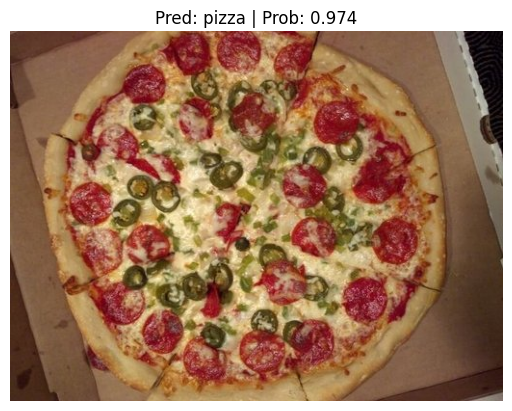

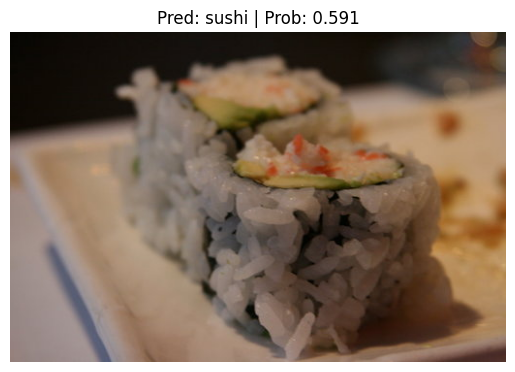

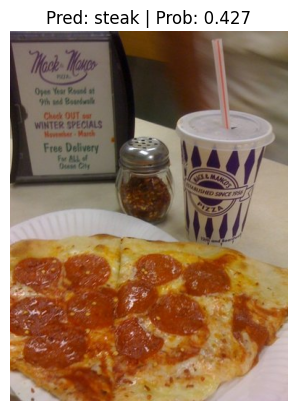

In [46]:
# 테스트 이미지 3개 랜덤으로 뽑아서 모델로 예측하고 결과를 눈으로 확인하는 코드
# 20% 테스트 데이터셋에서 랜덤으로 3개 이미지 선택
import random
num_images_to_plot = 3
test_image_path_list = list(Path(data_20_percent_path / "test").glob("*/*.jpg")) # test 폴더 안의 모든 jpg 이미지 경로 가져오기
test_image_path_sample = random.sample(population=test_image_path_list,
                                       k=num_images_to_plot) # randomly select 3 number of images

# 선택된 이미지들을 하나씩 돌면서 예측하고 시각화
for image_path in test_image_path_sample:
    pred_and_plot_image(model=best_model,
                        image_path=image_path,      # 현재 이미지
                        class_names=class_names,
                        image_size=(224, 224))

# 9.1 최적의 모델 사용해 커스텀 이미지 예측하기

data\04-pizza-dad.jpeg already exists, skipping download.


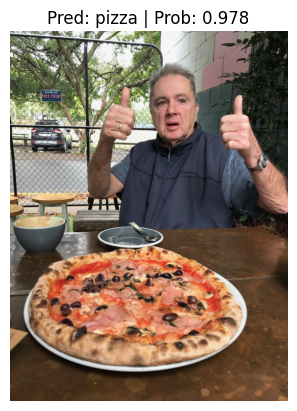

In [48]:
# Download custom image
import requests

# Setup custom image path
custom_image_path = Path("data/04-pizza-dad.jpeg")

# Download the image if it doesn't already exist
if not custom_image_path.is_file():
    with open(custom_image_path, "wb") as f:
        # When downloading from GitHub, need to use the "raw" file link
        request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/04-pizza-dad.jpeg")
        print(f"Downloading {custom_image_path}...")
        f.write(request.content)
else:
    print(f"{custom_image_path} already exists, skipping download.")

# Predict on custom image
pred_and_plot_image(model=model,
                    image_path=custom_image_path,
                    class_names=class_names)